In [1]:
# Import libraries

import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Load cleaned orders

orders = pd.read_csv(
    "../data/cleaned/orders_clean.csv"
)

# Load reviews

reviews = pd.read_csv(
    "../data/olist_order_reviews_dataset.csv"
)

print("Data Loaded Successfully")

Data Loaded Successfully


In [3]:
# Convert date columns

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_estimated_delivery_date"] = pd.to_datetime(
    orders["order_estimated_delivery_date"]
)

In [4]:
# Calculate delivery days

orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

print(
    "Average Delivery Days:",
    round(orders["delivery_days"].mean(), 2)
)

Average Delivery Days: 12.09


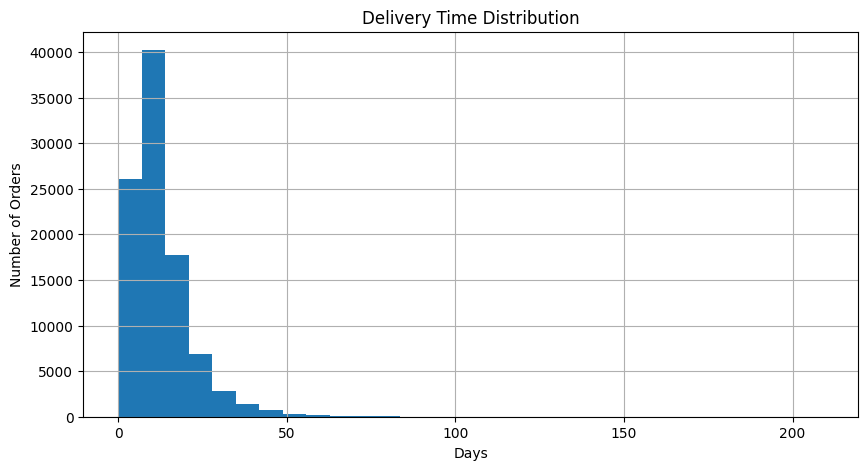

In [5]:
# Delivery days histogram

plt.figure(figsize=(10,5))

orders["delivery_days"].dropna().hist(
    bins=30
)

plt.title(
    "Delivery Time Distribution"
)

plt.xlabel(
    "Days"
)

plt.ylabel(
    "Number of Orders"
)

plt.show()

In [6]:
# Check if order was late

orders["late_delivery"] = (
    orders["order_delivered_customer_date"]
    >
    orders["order_estimated_delivery_date"]
)

In [7]:
# Count late deliveries

orders["late_delivery"].value_counts()

late_delivery
False    91614
True      7827
Name: count, dtype: int64

In [8]:
# Review ratings

reviews["review_score"].value_counts().sort_index()

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

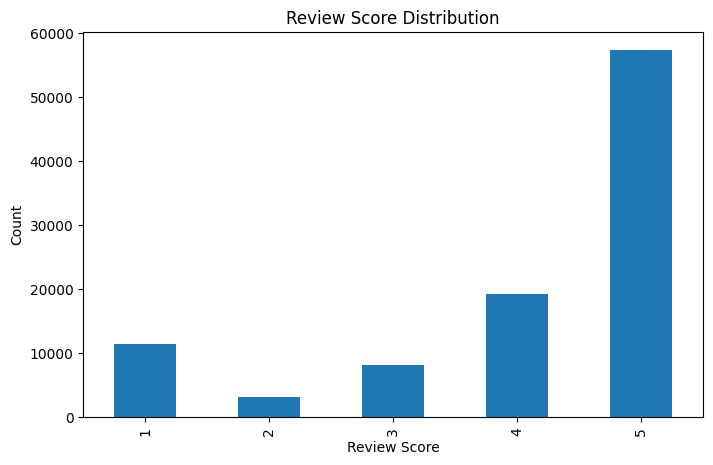

In [9]:
# Review score chart

reviews["review_score"]\
    .value_counts()\
    .sort_index()\
    .plot(
        kind="bar",
        figsize=(8,5)
    )

plt.title(
    "Review Score Distribution"
)

plt.xlabel(
    "Review Score"
)

plt.ylabel(
    "Count"
)

plt.show()

In [10]:
# Combine orders and reviews

review_analysis = orders.merge(
    reviews,
    on="order_id",
    how="inner"
)

In [11]:
# Compare ratings

review_analysis.groupby(
    "late_delivery"
)["review_score"].mean()

late_delivery
False    4.214307
True     2.566550
Name: review_score, dtype: float64